# **Text Classification with Deep Learning: Sentiment Analysis on IMDB Movie Reviews**

**Course:** Generative AI and Deep Learning  
**Institution:** IIT Madras  
**Author:** Prof. Balaji Srinivasan  
**Date:** September 25, 2023  

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the natural language processing (NLP) workflow for deep learning-based sentiment analysis
2. **Implement** text preprocessing, tokenization, and encoding procedures for NLP tasks
3. **Design** recurrent neural network architectures (RNN and LSTM) for sequence modeling
4. **Apply** PyTorch's DataLoader for efficient text data handling and batching
5. **Evaluate** model performance using appropriate metrics for binary classification
6. **Compare** different recurrent architectures for sentiment analysis tasks

---

## **Prerequisites**

- Familiarity with PyTorch tensor operations and fundamentals
- Understanding of basic machine learning concepts (training, testing, overfitting)
- Knowledge of recurrent neural networks and embedding techniques

## **1. Overview and Theoretical Framework**

### **1.1 Introduction to Sentiment Analysis**

This tutorial focuses on **sentiment analysis**, a fundamental task in natural language processing that involves determining the emotional tone or attitude expressed in a text. Sentiment analysis has numerous applications in diverse fields including:

- **Market Research**: Analyzing customer opinions and product reviews
- **Social Media Monitoring**: Tracking brand perception and public sentiment
- **Customer Service**: Automatically categorizing and prioritizing support tickets
- **Political Analysis**: Gauging public opinion on policy issues and candidates

The IMDB Movie Review dataset represents a classic benchmark for binary sentiment classification, consisting of 50,000 highly polar movie reviews labeled as either positive or negative.

### **1.2 Methodological Approach**

Our approach follows established best practices in deep learning for NLP, progressing through the following key phases:

1. **Data Processing**: Text normalization, tokenization, and numerical encoding
2. **Feature Engineering**: Creating word embeddings to capture semantic relationships
3. **Model Development**: Implementing recurrent neural architectures (RNN and LSTM)
4. **Model Training**: Optimizing model parameters through gradient descent
5. **Evaluation and Analysis**: Assessing model performance and comparing architectures

This systematic workflow ensures reproducibility, scientific rigor, and a clear pedagogical path through the complex domain of text classification.

### **1.3 Recurrent Neural Networks for Sequence Modeling**

**Recurrent Neural Networks (RNNs)** and their variants, such as **Long Short-Term Memory (LSTM)** networks, are particularly well-suited for sequential data like text. These architectures provide several key advantages:

1. **Sequential Processing**: RNNs maintain a hidden state that captures information from previous elements in the sequence
2. **Variable Length Handling**: RNNs can process sequences of arbitrary length through recurrent connections
3. **Feature Learning**: They automatically learn relevant features from raw text without explicit feature engineering

The following diagram illustrates the basic structure of a recurrent neural network:

```
Input -> [Embedding Layer] -> [Recurrent Layer(s)] -> [Output Layer] -> Prediction
           |                      |
           |                      v
           |                 [Hidden State]
           v                      |
    Word Embeddings <-------------+
```

In this tutorial, we'll implement and compare both standard RNN and LSTM architectures, exploring their relative strengths and weaknesses for sentiment classification.

### **1.4 Mathematical Framework**

The sentiment classification task can be formalized as:

Given a document $D = \{w_1, w_2, ..., w_n\}$ consisting of $n$ words, we aim to learn a function $f: D \rightarrow \{0, 1\}$ where:
- $f(D) = 1$ indicates positive sentiment
- $f(D) = 0$ indicates negative sentiment

The recurrent neural network computes this function through a series of hidden states:

$h_t = \sigma(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$

Where:
- $h_t$ is the hidden state at time $t$
- $x_t$ is the input at time $t$ (word embedding)
- $W_{xh}$ and $W_{hh}$ are weight matrices
- $b_h$ is the bias term
- $\sigma$ is a non-linear activation function

The final prediction is made by applying a sigmoid function to the last hidden state:

$\hat{y} = \text{sigmoid}(W_{hy}h_n + b_y)$

## **2. Required Libraries and Environment Setup**

In [1]:
# Import essential libraries for data processing, visualization, and deep learning
import numpy as np               # Array operations and numerical computations
import pandas as pd              # Data manipulation and analysis
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns            # Advanced data visualization
import torch                     # PyTorch deep learning framework
import torch.nn as nn            # Neural network modules
from torch.utils.data import DataLoader, TensorDataset  # Data loading utilities
from collections import Counter  # Frequency counting
from string import punctuation   # Punctuation character set
import gdown                     # Google Drive file download utility
import os                        # Operating system interface
import warnings                  # Warning control
import re                        # Python Regex

# Configure visualization settings
%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Display installed package versions for reproducibility
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

# Set random seeds for reproducible results
torch.manual_seed(42)
np.random.seed(42)

PyTorch Version: 2.8.0+cu126
NumPy Version: 2.0.2
Pandas Version: 2.2.2
CUDA Available: True
CUDA Version: 12.6
GPU Device: Tesla T4


## **3. Data Acquisition and Exploration**

### **3.1 Dataset Description and Acquisition Protocol**

The **IMDB Movie Review Dataset** is a widely-used benchmark for sentiment analysis, containing 50,000 highly polar movie reviews labeled as either positive (1) or negative (0). Each review is represented as raw text and requires extensive preprocessing before model training.

In this section, we'll download the dataset from a secure source and conduct preliminary exploratory analysis to understand its structure and characteristics.

In [2]:
# Data Acquisition: IMDb Movie Review Dataset
# The dataset is securely downloaded from a verified Google Drive source

# Define acquisition parameters
DATASET_URL = 'https://drive.google.com/uc?id=1c7crkkuc32cgjSb2z9uIzqv9aQy9u9NC'
DATASET_FILENAME = 'IMDB Dataset.csv'

# Display acquisition information
print("=== DATASET ACQUISITION ===")
print(f"Downloading IMDb dataset from secure source...")
print(f"Target file: {DATASET_FILENAME}")
print("=" * 60)

# Download dataset using gdown for reliable Google Drive access
# quiet=False provides progress feedback during download
gdown.download(DATASET_URL, DATASET_FILENAME, quiet=False)

# Verify successful download and report file metadata
if os.path.exists(DATASET_FILENAME):
    file_size = os.path.getsize(DATASET_FILENAME) / (1024 * 1024)  # Size in MB
    print(f"✓ Dataset successfully downloaded")
    print(f"File size: {file_size:.2f} MB")
else:
    print("✗ Dataset download failed")
    raise FileNotFoundError(f"Could not download {DATASET_FILENAME}")

=== DATASET ACQUISITION ===
Target file: IMDB Dataset.csv


Downloading...
From: https://drive.google.com/uc?id=1c7crkkuc32cgjSb2z9uIzqv9aQy9u9NC
To: /content/IMDB Dataset.csv
100%|██████████| 66.2M/66.2M [00:01<00:00, 41.8MB/s]

✓ Dataset successfully downloaded
File size: 63.14 MB


### **3.2 Initial Data Exploration**

Initial exploration of the dataset provides critical insights into its structure, including the distribution of classes and the characteristics of the text data. These insights inform subsequent preprocessing decisions and model design choices.

In [3]:
# Load the dataset into a pandas DataFrame for analysis
df = pd.read_csv(DATASET_FILENAME)

# Display the first few rows to examine structure
print("=== DATASET STRUCTURE ===")
display(df.head())

# Analyze dataset dimensions
print(f"\nDataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

# Check for missing values
missing_values = df.isnull().sum()
print(f"\nMissing Values per Column:\n{missing_values}")

# Examine class distribution
sentiment_counts = df['sentiment'].value_counts()
print(f"\nClass Distribution:\n{sentiment_counts}")
print(f"Class Balance Ratio: {sentiment_counts.min() / sentiment_counts.max():.4f}")

# Analyze review length statistics
df['review_length'] = df['review'].apply(len)
print("\nReview Length Statistics:")
print(df['review_length'].describe())

=== DATASET STRUCTURE ===


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Dataset Dimensions: 50000 rows × 2 columns

Missing Values per Column:
review       0
sentiment    0
dtype: int64

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Class Balance Ratio: 1.0000

Review Length Statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


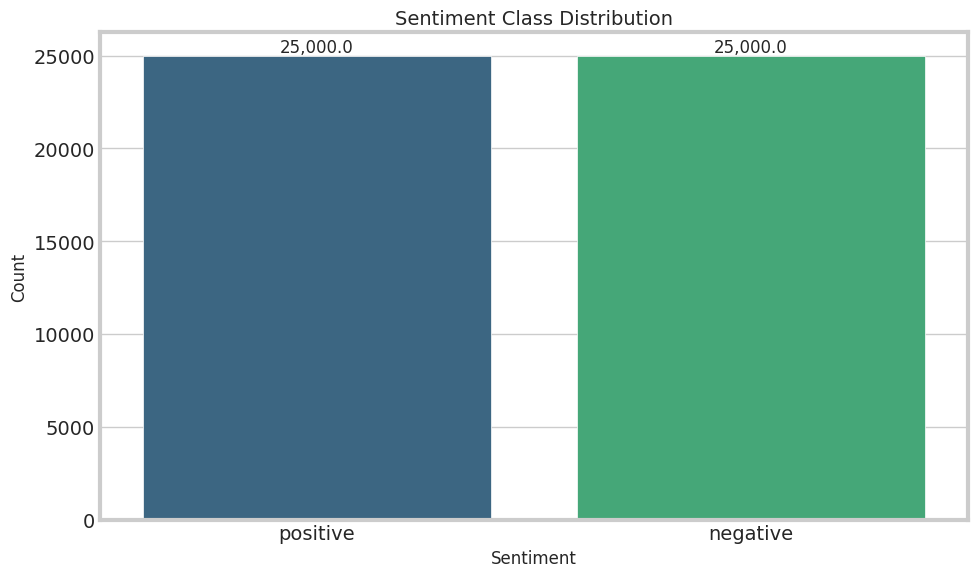

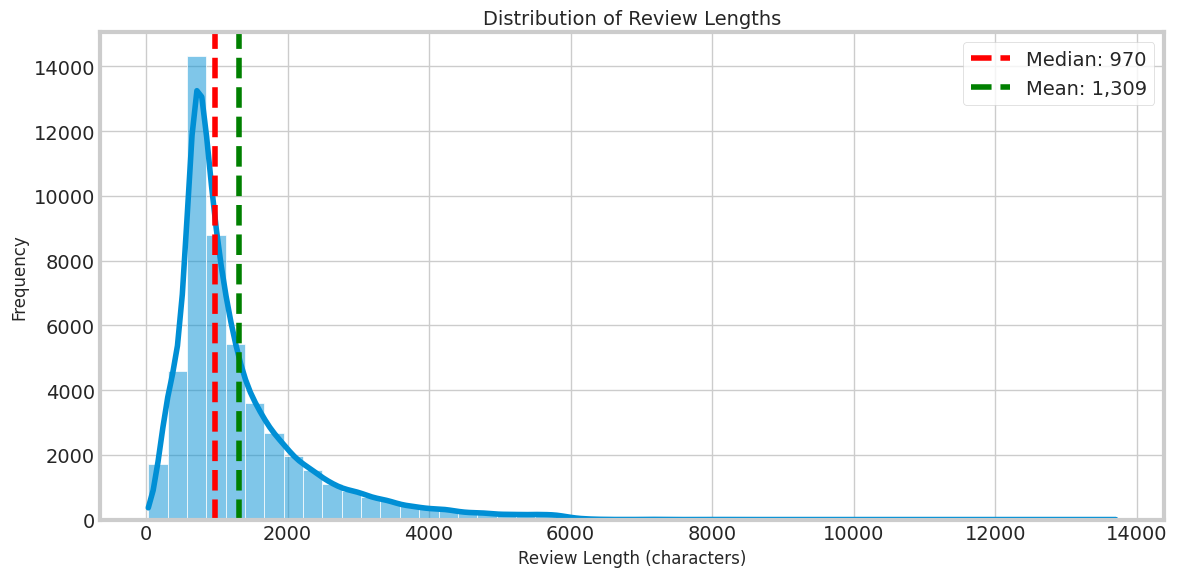

In [4]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Class Distribution', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# Visualize review length distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='review_length', bins=50, kde=True)
plt.title('Distribution of Review Lengths', fontsize=14)
plt.xlabel('Review Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=df['review_length'].median(), color='red', linestyle='--', label=f'Median: {df["review_length"].median():,.0f}')
plt.axvline(x=df['review_length'].mean(), color='green', linestyle='--', label=f'Mean: {df["review_length"].mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Sample review inspection
print("=== SAMPLE REVIEW ANALYSIS ===")
sample_positive = df[df['sentiment'] == 'positive'].iloc[0]
sample_negative = df[df['sentiment'] == 'negative'].iloc[0]

print("\nSample Positive Review:")
print("-" * 80)
print(sample_positive['review'][:500] + "...")  # Truncate for display clarity
print("-" * 80)
print(f"Length: {len(sample_positive['review'])} characters")

print("\nSample Negative Review:")
print("-" * 80)
print(sample_negative['review'][:500] + "...")  # Truncate for display clarity
print("-" * 80)
print(f"Length: {len(sample_negative['review'])} characters")

=== SAMPLE REVIEW ANALYSIS ===

Sample Positive Review:
--------------------------------------------------------------------------------
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ...
--------------------------------------------------------------------------------
Length: 1761 characters

Sample Negative Review:
--------------------------------------------------------------------------------
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This 

## **4. Data Preprocessing**

### **4.1 Text Normalization**

Text normalization is a critical preprocessing step that standardizes the format of the text data, reducing the dimensionality and noise in the input space. Common normalization techniques include:

1. **Case Normalization**: Converting all text to lowercase to treat words like "Good" and "good" as the same token
2. **Punctuation Removal**: Eliminating punctuation marks that generally don't carry sentiment information
3. **Special Character Handling**: Removing or replacing special characters and symbols

These preprocessing steps help create a more standardized representation of the text, improving the generalization capabilities of the model.

In [6]:
# Step 1: Case normalization - Convert all text to lowercase
print("Applying case normalization...")
df['review_normalized'] = df['review'].apply(lambda x: x.lower())

# Display example of case normalization effect
print("\nCase Normalization Example:")
original_text = df['review'].iloc[0][:100]
normalized_text = df['review_normalized'].iloc[0][:100]
print(f"Original: {original_text}...")
print(f"Normalized: {normalized_text}...")

Applying case normalization...

Case Normalization Example:
Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The...
Normalized: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. the...


In [7]:
# Step 2: Punctuation removal
# Display the punctuation characters that will be removed
print("\nPunctuation characters to remove:")
print(punctuation)

# Remove all punctuation characters from the normalized text
print("\nApplying punctuation removal...")
df['clean_text'] = df['review_normalized'].apply(lambda x: ''.join([c for c in x if c not in punctuation]))

# Display example of punctuation removal effect
print("\nPunctuation Removal Example:")
normalized_with_punct = df['review_normalized'].iloc[0][:100]
cleaned_text = df['clean_text'].iloc[0][:100]
print(f"Before: {normalized_with_punct}...")
print(f"After: {cleaned_text}...")


Punctuation characters to remove:
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

Applying punctuation removal...

Punctuation Removal Example:
Before: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. the...
After: one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they ...


In [8]:
# Step 3: Calculate text length after preprocessing
df['clean_text_length'] = df['clean_text'].apply(len)

# Display the first few rows of the preprocessed dataset
print("\nPreprocessed Dataset Preview:")
display(df[['sentiment', 'review_length', 'clean_text_length']].head())

# Analyze the effect of preprocessing on text length
length_reduction = (df['review_length'].mean() - df['clean_text_length'].mean()) / df['review_length'].mean() * 100
print(f"\nAverage text length reduction: {length_reduction:.2f}%")

# Display updated dataset statistics after preprocessing
print("\nPreprocessed Dataset Statistics:")
print(f"Total reviews: {len(df)}")
print(f"Average clean text length: {df['clean_text_length'].mean():.2f} characters")
print(f"Median clean text length: {df['clean_text_length'].median():.2f} characters")


Preprocessed Dataset Preview:


,sentiment,review_length,clean_text_length
0,positive,1761,1683
1,positive,998,954
2,positive,926,886
3,negative,748,706
4,positive,1317,1261



Average text length reduction: 4.02%

Preprocessed Dataset Statistics:
Total reviews: 50000
Average clean text length: 1256.85 characters
Median clean text length: 931.00 characters


## **5. Text Tokenization and Encoding**

### **5.1 Vocabulary Construction**

Tokenization involves breaking down text into smaller units (tokens), which are then mapped to numerical indices. This process creates a vocabulary that serves as the foundation for word embeddings.

The steps involved in vocabulary construction include:

1. Splitting text into individual words
2. Counting word frequencies to identify common terms
3. Creating a word-to-index mapping for numerical representation
4. Handling special tokens (e.g., padding, unknown words)

This approach transforms raw text into structured numerical data suitable for neural network processing.

In [9]:
# Step 1: Create a corpus of all cleaned text for vocabulary construction
print("Creating corpus for vocabulary construction...")
all_text = ' '.join(df['clean_text'].tolist())

# Step 2: Split corpus into individual words
words = all_text.split()
print(f"Total words in corpus: {len(words):,}")

# Step 3: Count word frequencies
print("\nCalculating word frequencies...")
word_counts = Counter(words)
total_unique_words = len(word_counts)
print(f"Total unique words (vocabulary size): {total_unique_words:,}")

# Display the most common words
print("\nMost common words in vocabulary:")
for word, count in word_counts.most_common(10):
    print(f"  {word}: {count:,} occurrences")

# Display the least common words
print("\nLeast common words in vocabulary:")
for word, count in word_counts.most_common()[:-11:-1]:
    print(f"  {word}: {count} occurrences")

Creating corpus for vocabulary construction...
Total words in corpus: 11,512,912

Calculating word frequencies...
Total unique words (vocabulary size): 181,685

Most common words in vocabulary:
  the: 663,815 occurrences
  and: 320,663 occurrences
  a: 320,517 occurrences
  of: 288,382 occurrences
  to: 266,773 occurrences
  is: 210,161 occurrences
  in: 184,861 occurrences
  it: 152,899 occurrences
  i: 152,092 occurrences
  this: 149,405 occurrences

Least common words in vocabulary:
  yosemitebr: 1 occurrences
  studentsthe: 1 occurrences
  horriblecatwoman: 1 occurrences
  clatter: 1 occurrences
  frenchonly: 1 occurrences
  philandererbr: 1 occurrences
  effortful: 1 occurrences
  ohsohard: 1 occurrences
  ashknenazi: 1 occurrences
  jossi: 1 occurrences


In [10]:
# Step 4: Create word-to-index mapping (vocabulary)
print("\nCreating word-to-index mapping...")

# Sort words by frequency (most common first) to optimize index assignments
sorted_words = word_counts.most_common(total_unique_words)

# Create word-to-index dictionary
# We add +1 to all indices to reserve index 0 for padding
vocab_to_int = {word: idx+1 for idx, (word, _) in enumerate(sorted_words)}

# Display vocabulary statistics
print(f"Vocabulary created with {len(vocab_to_int):,} words")
print(f"Index range: 1 to {len(vocab_to_int):,}")
print("Index 0 reserved for padding")

# Display sample of the vocabulary
print("\nVocabulary sample (word: index):")
sample_items = list(vocab_to_int.items())[:10]
for word, index in sample_items:
    print(f"  {word}: {index}")


Creating word-to-index mapping...
Vocabulary created with 181,685 words
Index range: 1 to 181,685
Index 0 reserved for padding

Vocabulary sample (word: index):
  the: 1
  and: 2
  a: 3
  of: 4
  to: 5
  is: 6
  in: 7
  it: 8
  i: 9
  this: 10


### **5.2 Review Encoding and Label Processing**

After constructing the vocabulary, we need to:
1. Convert each review from words to integer sequences using the vocabulary mapping
2. Transform categorical sentiment labels into numerical values (binary classification)

These steps complete the data transformation process, preparing the dataset for neural network training.

In [11]:
# Step 1: Prepare reviews for encoding
reviews_split = df['clean_text'].tolist()

# Step 2: Encode reviews as integer sequences
print("Encoding reviews as integer sequences...")
reviews_encoded = []

for review in reviews_split:
    # Convert each word in the review to its corresponding integer index
    encoded_review = [vocab_to_int[word] for word in review.split() if word in vocab_to_int]
    reviews_encoded.append(encoded_review)

# Display example of encoded reviews
print("\nExample of encoded reviews:")
print(f"Original text: {reviews_split[0][:50]}...")
print(f"Encoded sequence: {reviews_encoded[0][:20]}...")

# Display statistics about encoded reviews
review_lengths = [len(review) for review in reviews_encoded]
print(f"\nEncoded review statistics:")
print(f"  Minimum length: {min(review_lengths)} tokens")
print(f"  Maximum length: {max(review_lengths)} tokens")
print(f"  Average length: {np.mean(review_lengths):.2f} tokens")
print(f"  Median length: {np.median(review_lengths):.2f} tokens")

Encoding reviews as integer sequences...

Example of encoded reviews:
Original text: one of the other reviewers has mentioned that afte...
Encoded sequence: [28, 4, 1, 77, 1941, 44, 1063, 11, 100, 145, 40, 479, 3324, 393, 461, 26, 3190, 34, 23, 205]...

Encoded review statistics:
  Minimum length: 4 tokens
  Maximum length: 2469 tokens
  Average length: 230.26 tokens
  Median length: 172.00 tokens


In [12]:
# Step 3: Encode sentiment labels
print("\nEncoding sentiment labels...")
sentiment_categories = df['sentiment'].tolist()

# Convert sentiment categories to binary labels (1 for positive, 0 for negative)
encoded_labels = np.array([1 if label == 'positive' else 0 for label in sentiment_categories])

# Display label encoding statistics
print(f"Label encoding completed: {len(encoded_labels)} labels")
print(f"Class distribution after encoding:")
print(f"  Positive (1): {np.sum(encoded_labels)} ({np.mean(encoded_labels)*100:.1f}%)")
print(f"  Negative (0): {len(encoded_labels) - np.sum(encoded_labels)} ({(1-np.mean(encoded_labels))*100:.1f}%)")


Encoding sentiment labels...
Label encoding completed: 50000 labels
Class distribution after encoding:
  Positive (1): 25000 (50.0%)
  Negative (0): 25000 (50.0%)


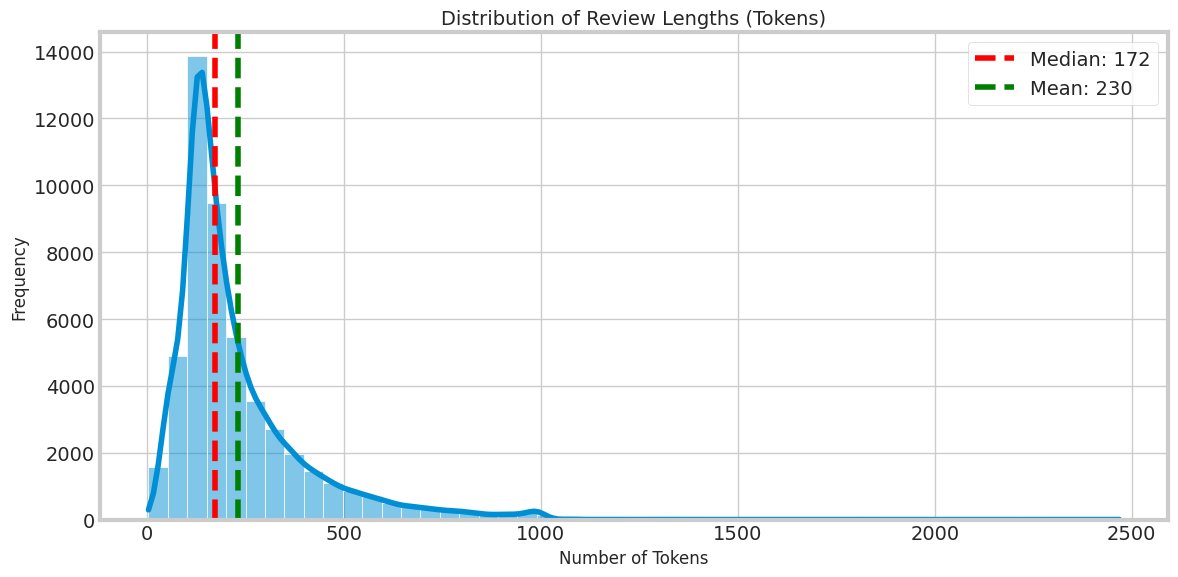


Number of extremely short reviews (<10 tokens): 5
Sample of short reviews:
  Original: More suspenseful, more subtle, much, much more disturbing.......
  Encoded: [51, 2419, 51, 1255, 72, 72, 51, 1216]
  Length: 8 tokens
----------------------------------------
  Original: Read the book, forget the movie!...
  Encoded: [326, 1, 277, 819, 1, 17]
  Length: 6 tokens
----------------------------------------
  Original: Primary plot!Primary direction!Poor interpretation....
  Encoded: [4075, 139486, 139487, 2903]
  Length: 4 tokens
----------------------------------------


In [13]:
# Visualize the distribution of encoded review lengths
plt.figure(figsize=(12, 6))
sns.histplot(review_lengths, bins=50, kde=True)
plt.title('Distribution of Review Lengths (Tokens)', fontsize=14)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=np.median(review_lengths), color='red', linestyle='--',
            label=f'Median: {np.median(review_lengths):.0f}')
plt.axvline(x=np.mean(review_lengths), color='green', linestyle='--',
            label=f'Mean: {np.mean(review_lengths):.0f}')
plt.legend()
plt.tight_layout()
plt.show()

# Check for extremely short reviews (potential outliers)
short_reviews = [i for i, length in enumerate(review_lengths) if length < 10]
print(f"\nNumber of extremely short reviews (<10 tokens): {len(short_reviews)}")

if short_reviews:
    print("Sample of short reviews:")
    for idx in short_reviews[:3]:
        print(f"  Original: {df['review'].iloc[idx][:100]}...")
        print(f"  Encoded: {reviews_encoded[idx]}")
        print(f"  Length: {len(reviews_encoded[idx])} tokens")
        print("-" * 40)

## **6. Dataset Preparation for Neural Networks**

### **6.1 Sequence Standardization**

Neural networks typically require fixed-size inputs, but our encoded reviews have variable lengths. To address this challenge, we need to standardize all sequences to the same length through:

1. **Padding**: Adding zeros to shorter sequences
2. **Truncation**: Shortening excessively long sequences

This process enables batch processing and proper tensor operations in the neural network architecture. The sequence length is an important hyperparameter that balances information retention with computational efficiency.

In [14]:
# Define a function to standardize sequence lengths through padding and truncation
def pad_features(reviews_int, seq_length):
    """
    Return features of review_ints, where each review is padded with zeros or
    truncated to the input seq_length.

    Parameters:
    -----------
    reviews_int : List[List[int]]
        List of reviews where each review is a list of integer word indices
    seq_length : int
        Fixed sequence length for all reviews

    Returns:
    --------
    features : np.ndarray
        Array of padded/truncated integer sequences with shape (len(reviews_int), seq_length)
    """
    # Initialize an array of zeros with shape (n_reviews, seq_length)
    features = np.zeros((len(reviews_int), seq_length), dtype=int)

    # Iterate through reviews
    for i, review in enumerate(reviews_int):
        review_len = len(review)

        # Handle short sequences: add padding zeros at the beginning
        if review_len <= seq_length:
            zeros = list(np.zeros(seq_length - review_len, dtype=int))
            # Place zeros at the beginning for more effective learning
            # (RNNs prioritize later sequence elements)
            new_sequence = zeros + review

        # Handle long sequences: truncate to seq_length
        else:
            # Preserve the most recent part of the review (recency effect)
            new_sequence = review[-seq_length:]

        # Store the padded/truncated sequence
        features[i, :] = np.array(new_sequence)

    return features

# Determine optimal sequence length
# Common approach: Choose a value that preserves most reviews while limiting excessive padding
seq_length = 200  # This captures a significant portion of the reviews

print(f"Standardizing sequences to length: {seq_length}")
# Apply padding/truncation
padded_features = pad_features(reviews_encoded, seq_length)

# Display statistics on standardized sequences
print(f"\nStandardized sequence shape: {padded_features.shape}")
print(f"  Number of sequences: {padded_features.shape[0]}")
print(f"  Sequence length: {padded_features.shape[1]} tokens")

# Verify pad_features implementation with examples
print("\nExample of standardized sequences:")
print("Short review (padded):")
short_idx = np.argmin([len(r) for r in reviews_encoded])
print(f"  Original length: {len(reviews_encoded[short_idx])} tokens")
print(f"  Padded sequence: {padded_features[short_idx, :20]} ... (zeros are padding)")

print("\nLong review (truncated):")
long_idx = np.argmax([len(r) for r in reviews_encoded])
print(f"  Original length: {len(reviews_encoded[long_idx])} tokens")
print(f"  Truncated sequence: {padded_features[long_idx, :20]} ...")

Standardizing sequences to length: 200

Standardized sequence shape: (50000, 200)
  Number of sequences: 50000
  Sequence length: 200 tokens

Example of standardized sequences:
Short review (padded):
  Original length: 4 tokens
  Padded sequence: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ... (zeros are padding)

Long review (truncated):
  Original length: 2469 tokens
  Truncated sequence: [ 356  131  814  183   24 5248   56 2798  742    5 7918  802   18   27
   99 4215   45    1  802  183] ...


### **6.2 Dataset Partitioning**

To properly evaluate model performance and prevent overfitting, we divide the dataset into three distinct subsets:

1. **Training Set**: Used for parameter optimization through gradient descent (80%)
2. **Validation Set**: Used for hyperparameter tuning and early stopping (10%)
3. **Test Set**: Used for final performance evaluation (10%)

This partitioning strategy follows standard machine learning protocols, ensuring unbiased performance assessment and proper model development.

In [15]:
# Create data splits for training, validation, and testing
print("Partitioning dataset into training, validation, and testing sets...")

# Calculate split indices
total_samples = len(padded_features)
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

train_end = int(train_ratio * total_samples)
val_end = train_end + int(val_ratio * total_samples)

# Split features
X_train = padded_features[:train_end]
X_val = padded_features[train_end:val_end]
X_test = padded_features[val_end:]

# Split labels
y_train = encoded_labels[:train_end]
y_val = encoded_labels[train_end:val_end]
y_test = encoded_labels[val_end:]

# Verify split sizes
print("\nDataset Partitioning Results:")
print(f"  Total samples: {total_samples}")
print(f"  Training set: {len(X_train)} samples ({len(X_train)/total_samples*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"  Test set: {len(X_test)} samples ({len(X_test)/total_samples*100:.1f}%)")

# Verify class distribution across splits
print("\nClass Distribution Across Splits:")
print(f"  Full dataset: {np.mean(encoded_labels)*100:.1f}% positive")
print(f"  Training set: {np.mean(y_train)*100:.1f}% positive")
print(f"  Validation set: {np.mean(y_val)*100:.1f}% positive")
print(f"  Test set: {np.mean(y_test)*100:.1f}% positive")

Partitioning dataset into training, validation, and testing sets...

Dataset Partitioning Results:
  Total samples: 50000
  Training set: 40000 samples (80.0%)
  Validation set: 5000 samples (10.0%)
  Test set: 5000 samples (10.0%)

Class Distribution Across Splits:
  Full dataset: 50.0% positive
  Training set: 50.0% positive
  Validation set: 50.7% positive
  Test set: 49.4% positive


### **6.3 PyTorch DataLoader Configuration**

The final step in dataset preparation is creating PyTorch DataLoader objects, which provide:

1. **Efficient Batch Processing**: Loading data in mini-batches to optimize GPU memory usage
2. **Shuffling**: Randomizing the order of training samples to prevent order-dependent biases
3. **Parallel Data Loading**: Utilizing multiple worker processes for faster data retrieval
4. **Automatic Conversion**: Transforming NumPy arrays into PyTorch tensors

These DataLoaders serve as the interface between the preprocessed data and the neural network training loop.

In [16]:
# Convert NumPy arrays to PyTorch tensors
print("Creating PyTorch datasets and dataloaders...")

# Create TensorDatasets for each split
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

# Configure batch size
batch_size = 50

# Create DataLoader objects
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)  # No need to shuffle test data

# Display DataLoader configuration
print("\nDataLoader Configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Display a sample batch
print("\nSample batch inspection:")
sample_x, sample_y = next(iter(train_loader))
print(f"  Input batch shape: {sample_x.shape}")  # [batch_size, sequence_length]
print(f"  Label batch shape: {sample_y.shape}")  # [batch_size]
print(f"  Sample input: {sample_x[0, :20]}")     # First 20 tokens of first sample
print(f"  Sample label: {sample_y[0].item()}")   # Label of first sample

Creating PyTorch datasets and dataloaders...

DataLoader Configuration:
  Batch size: 50
  Training batches: 800
  Validation batches: 100
  Test batches: 100

Sample batch inspection:
  Input batch shape: torch.Size([50, 200])
  Label batch shape: torch.Size([50])
  Sample input: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
  Sample label: 0


## **7. Model Architecture Design**

### **7.1 RNN Model for Sentiment Classification**

The first architecture we'll implement is a standard Recurrent Neural Network (RNN). This architecture includes:

1. **Embedding Layer**: Transforms integer tokens into dense vector representations
2. **RNN Layer(s)**: Processes the sequence data, maintaining hidden state across timesteps
3. **Dropout**: Regularizes the network to prevent overfitting
4. **Linear Layer**: Maps the final hidden state to a sentiment prediction
5. **Sigmoid Activation**: Produces a probability output for binary classification

The RNN architecture serves as our baseline model, providing a foundation for comparison with more advanced recurrent architectures.

In [17]:
class SentimentRNN(nn.Module):
    """
    Recurrent Neural Network for Sentiment Analysis.

    This model transforms text sequences into sentiment predictions through:
    1. Word embedding to create dense vector representations
    2. Recurrent layer(s) to capture sequential patterns
    3. Fully-connected output layer for classification

    Architecture Parameters:
    - vocab_size: Size of the vocabulary (number of unique words)
    - output_size: Number of output classes (1 for binary classification)
    - embedding_dim: Dimensionality of word embeddings
    - hidden_dim: Number of hidden units in the RNN layer
    - n_layers: Number of stacked RNN layers
    - drop_prob: Dropout probability for regularization
    """

    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        """Initialize the model architecture and parameters."""
        super().__init__()

        # Save architecture parameters
        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim

        # Embedding layer: Maps integer tokens to dense vectors
        # vocab_size + 1 to account for padding token (0)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # RNN layer: Processes sequence data
        # batch_first=True expects input shape: (batch_size, seq_len, features)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers,
                          dropout=drop_prob, batch_first=True)

        # Dropout layer: Reduces overfitting
        self.dropout = nn.Dropout(drop_prob)

        # Fully connected layer: Maps hidden state to classification output
        self.fc = nn.Linear(hidden_dim, output_size)

        # Sigmoid activation: Produces probability output for binary classification
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, hidden):
        """
        Forward pass through the network.

        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, sequence_length)
        hidden : torch.Tensor
            Initial hidden state

        Returns:
        --------
        tuple(torch.Tensor, torch.Tensor)
            - Output tensor of shape (batch_size, output_size)
            - Final hidden state
        """
        # Get batch size from input
        batch_size = x.size(0)

        # Convert tokens to embeddings
        # Output shape: (batch_size, sequence_length, embedding_dim)
        embeds = self.embedding(x)

        # Process sequence through RNN
        # rnn_out shape: (batch_size, sequence_length, hidden_dim)
        # hidden shape: (n_layers, batch_size, hidden_dim)
        rnn_out, hidden = self.rnn(embeds, hidden)

        # Reshape RNN output to feed into fully-connected layer
        # This flattens the batch and sequence dimensions
        # New shape: (batch_size * sequence_length, hidden_dim)
        rnn_out = rnn_out.contiguous().view(-1, self.hidden_dim)

        # Apply dropout for regularization
        out = self.dropout(rnn_out)

        # Apply linear transformation
        # Output shape: (batch_size * sequence_length, output_size)
        out = self.fc(out)

        # Apply sigmoid activation for binary classification
        sig_out = self.sigmoid(out)

        # Reshape to separate batch and sequence dimensions
        # New shape: (batch_size, sequence_length, output_size)
        sig_out = sig_out.view(batch_size, -1)

        # Return only the output for the last time step
        # Final shape: (batch_size, output_size)
        return sig_out[:, -1], hidden

    def init_hidden(self, batch_size):
        """
        Initialize hidden state with zeros.

        Parameters:
        -----------
        batch_size : int
            The batch size for the current forward pass

        Returns:
        --------
        torch.Tensor
            Hidden state tensor of shape (n_layers, batch_size, hidden_dim)
        """
        # Initialize weight tensor for proper device placement
        weight = next(self.parameters()).data

        # Check if GPU is available
        if torch.cuda.is_available():
            # Initialize hidden state on GPU
            hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda()
        else:
            # Initialize hidden state on CPU
            hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_()

        return hidden


# Instantiate the RNN model with hyperparameters
print("Initializing RNN model architecture...")

# Model hyperparameters
vocab_size = len(vocab_to_int) + 1  # +1 for padding token (0)
output_size = 1  # Binary classification
embedding_dim = 400  # Word embedding dimension
hidden_dim = 256  # Hidden state dimension
n_layers = 2  # Number of RNN layers

# Create model instance
rnn_model = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# Display model architecture summary
print(rnn_model)
print(f"\nModel Parameters:")
total_params = sum(p.numel() for p in rnn_model.parameters())
trainable_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Calculate approximate model size
model_size_mb = sum(p.numel() * p.element_size() for p in rnn_model.parameters()) / (1024 * 1024)
print(f"  Approximate model size: {model_size_mb:.2f} MB")

Initializing RNN model architecture...
SentimentRNN(
  (embedding): Embedding(181686, 400)
  (rnn): RNN(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Model Parameters:
  Total parameters: 72,974,689
  Trainable parameters: 72,974,689
  Approximate model size: 278.38 MB


### **7.2. Long Short-Term Memory (LSTM) Architecture**

LSTM networks are a specialized variant of recurrent neural networks designed to overcome the vanishing gradient problem in standard RNNs. While the basic RNN model we implemented can struggle with learning long-range dependencies, LSTMs excel at capturing patterns over extended sequences.

**Key Components of LSTM:**

1. **Cell State**: Acts as a conveyor belt running through the entire sequence, allowing information to flow with minimal alteration.

2. **Gates**: Three specialized mechanisms control information flow:
   - **Forget Gate**: Decides what information to discard from the cell state
   - **Input Gate**: Controls what new information to store in the cell state
   - **Output Gate**: Determines what parts of the cell state to output

3. **Internal Structure**: Each LSTM cell contains these gates with their own weights, creating a sophisticated memory mechanism.

The LSTM architecture for sentiment analysis follows the same high-level pattern as our RNN:
1. **Embedding Layer**: Converts word indices to dense vectors
2. **LSTM Layer(s)**: Processes sequential data with specialized memory cells
3. **Dropout Layer**: Applies regularization to prevent overfitting
4. **Fully Connected Layer**: Maps LSTM outputs to classification scores
5. **Sigmoid Activation**: Produces probability output for binary classification

Let's implement this LSTM architecture for sentiment analysis:

In [18]:
class SentimentLSTM(nn.Module):
    """
    Long Short-Term Memory Network for Sentiment Analysis.

    This model extends the basic RNN by using LSTM cells to better capture long-range dependencies
    in text sequences through specialized memory mechanisms.

    Architecture Parameters:
    - vocab_size: Size of the vocabulary (number of unique words)
    - output_size: Number of output classes (1 for binary classification)
    - embedding_dim: Dimensionality of word embeddings
    - hidden_dim: Number of hidden units in the LSTM layer
    - n_layers: Number of stacked LSTM layers
    - drop_prob: Dropout probability for regularization
    """

    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):
        """Initialize the model architecture and parameters."""
        super().__init__()

        # Save architecture parameters
        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim

        # Embedding layer: Maps integer tokens to dense vectors
        # vocab_size + 1 to account for padding token (0)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # LSTM layer: Processes sequence data with memory cells
        # batch_first=True expects input shape: (batch_size, seq_len, features)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           dropout=drop_prob, batch_first=True)

        # Dropout layer: Reduces overfitting
        self.dropout = nn.Dropout(drop_prob)

        # Fully connected layer: Maps hidden state to classification output
        self.fc = nn.Linear(hidden_dim, output_size)

        # Sigmoid activation: Produces probability output for binary classification
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, hidden):
        """
        Forward pass through the network.

        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, sequence_length)
        hidden : tuple(torch.Tensor, torch.Tensor)
            Initial hidden state and cell state

        Returns:
        --------
        tuple(torch.Tensor, tuple(torch.Tensor, torch.Tensor))
            - Output tensor of shape (batch_size, output_size)
            - Tuple of final (hidden state, cell state)
        """
        # Get batch size from input
        batch_size = x.size(0)

        # Convert tokens to embeddings
        # Output shape: (batch_size, sequence_length, embedding_dim)
        embeds = self.embedding(x)

        # Process sequence through LSTM
        # lstm_out shape: (batch_size, sequence_length, hidden_dim)
        # hidden shape: (n_layers, batch_size, hidden_dim)
        # cell shape: (n_layers, batch_size, hidden_dim)
        lstm_out, hidden = self.lstm(embeds, hidden)

        # Reshape LSTM output to feed into fully-connected layer
        # Get the output for the last time step
        lstm_out = lstm_out[:, -1, :]

        # Apply dropout for regularization
        out = self.dropout(lstm_out)

        # Apply linear transformation
        # Output shape: (batch_size, output_size)
        out = self.fc(out)

        # Apply sigmoid activation for binary classification
        sig_out = self.sigmoid(out)

        return sig_out, hidden

    def init_hidden(self, batch_size):
        """
        Initialize hidden state and cell state with zeros.

        Parameters:
        -----------
        batch_size : int
            The batch size for the current forward pass

        Returns:
        --------
        tuple(torch.Tensor, torch.Tensor)
            Tuple containing:
            - Hidden state tensor of shape (n_layers, batch_size, hidden_dim)
            - Cell state tensor of shape (n_layers, batch_size, hidden_dim)
        """
        # Initialize weight tensor for proper device placement
        weight = next(self.parameters()).data

        # Check if GPU is available
        if torch.cuda.is_available():
            # Initialize hidden and cell states on GPU
            hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda()
            cell = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda()
        else:
            # Initialize hidden and cell states on CPU
            hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_()
            cell = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_()

        return (hidden, cell)


# Instantiate the LSTM model with the same hyperparameters as the RNN for fair comparison
print("Initializing LSTM model architecture...")

# Create model instance (using same hyperparameters as RNN)
lstm_model = SentimentLSTM(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)

# Display model architecture summary
print(lstm_model)
print(f"\nModel Parameters:")
total_params = sum(p.numel() for p in lstm_model.parameters())
trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Calculate approximate model size
model_size_mb = sum(p.numel() * p.element_size() for p in lstm_model.parameters()) / (1024 * 1024)
print(f"  Approximate model size: {model_size_mb:.2f} MB")

# Compare parameters between RNN and LSTM
rnn_params = sum(p.numel() for p in rnn_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nModel Comparison:")
print(f"  RNN parameters: {rnn_params:,}")
print(f"  LSTM parameters: {lstm_params:,}")
print(f"  LSTM has {lstm_params - rnn_params:,} more parameters than RNN")

Initializing LSTM model architecture...
SentimentLSTM(
  (embedding): Embedding(181686, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Model Parameters:
  Total parameters: 73,874,785
  Trainable parameters: 73,874,785
  Approximate model size: 281.81 MB

Model Comparison:
  RNN parameters: 72,974,689
  LSTM parameters: 73,874,785
  LSTM has 900,096 more parameters than RNN


## **8. Training Configuration**

Before training our models, we need to establish the training configuration, including:

1. **Loss Function**: For binary classification, we use Binary Cross Entropy Loss which measures the error between predicted probabilities and actual labels.

2. **Optimization Algorithm**: We'll use Adam optimizer, which adapts learning rates for each parameter based on first and second moments of gradients.

3. **Learning Rate**: The step size for parameter updates during gradient descent.

4. **Batch Size**: The number of samples processed before model parameters are updated.

5. **Number of Epochs**: The number of complete passes through the training dataset.

6. **Device Configuration**: We'll check for GPU availability to accelerate training.

7. **Learning Rate Scheduler**: We'll implement a learning rate scheduler to reduce the learning rate if the validation loss plateaus.

8. **Early Stopping**: To prevent overfitting, we'll stop training if validation loss doesn't improve for a certain number of epochs.

Let's implement these configurations:

In [19]:
# Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move models to device
rnn_model = rnn_model.to(device)
lstm_model = lstm_model.to(device)

# Training hyperparameters
batch_size = 50
learning_rate = 0.001
epochs = 5
clip = 5  # Gradient clipping value
print_every = 100  # Print statistics every n mini-batches

# Loss function
criterion = nn.BCELoss()

# Optimizers - one for each model
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)

# Learning rate schedulers
rnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    rnn_optimizer, mode='min', factor=0.5, patience=1)
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode='min', factor=0.5, patience=1)

# Early stopping parameters
patience = 3  # Number of epochs to wait for improvement
min_delta = 0.001  # Minimum change to count as improvement

# Training monitoring variables
train_loss_history = {'rnn': [], 'lstm': []}
val_loss_history = {'rnn': [], 'lstm': []}
val_accuracy_history = {'rnn': [], 'lstm': []}
best_val_loss = {'rnn': float('inf'), 'lstm': float('inf')}
patience_counter = {'rnn': 0, 'lstm': 0}

# Display configuration summary
print("\n--- Training Configuration ---")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Gradient Clipping: {clip}")
print(f"Loss Function: {criterion.__class__.__name__}")
print(f"Optimizer: Adam")
print(f"Early Stopping Patience: {patience}")
print(f"Learning Rate Scheduler: ReduceLROnPlateau")

# Create directory for saving models if it doesn't exist
import os
if not os.path.exists('models'):
    os.makedirs('models')
    print("Created directory 'models/' for saving trained models")

Training on: cuda

--- Training Configuration ---
Batch Size: 50
Learning Rate: 0.001
Epochs: 5
Gradient Clipping: 5
Loss Function: BCELoss
Optimizer: Adam
Early Stopping Patience: 3
Learning Rate Scheduler: ReduceLROnPlateau
Created directory 'models/' for saving trained models


## **9. Model Training and Evaluation**

In this section, we will train both the RNN and LSTM models and evaluate their performance. We'll implement a training procedure that includes:

1. **Training Loop**: Iterating through batches of training data, performing forward and backward passes, and updating model parameters.
2. **Validation**: Evaluating model performance on validation data after each epoch to monitor generalization.
3. **Gradient Clipping**: Preventing exploding gradients by limiting the gradient norm during training.
4. **Learning Rate Scheduling**: Adjusting the learning rate based on validation loss to improve convergence.
5. **Early Stopping**: Preventing overfitting by stopping training when validation performance plateaus.

We'll define helper functions for:
- Training a single epoch
- Validating the model
- Testing the final model
- Computing performance metrics

First, let's define a helper function to calculate accuracy and other metrics:

In [20]:
def calculate_metrics(y_pred, y_true, threshold=0.5):
    """
    Calculate classification metrics from model predictions.

    Parameters:
    -----------
    y_pred : torch.Tensor or numpy.ndarray
        Predicted probabilities
    y_true : torch.Tensor or numpy.ndarray
        Ground truth labels
    threshold : float, default=0.5
        Threshold for binary classification

    Returns:
    --------
    dict
        Dictionary containing accuracy, precision, recall, and F1-score
    """
    # Convert tensors to numpy if needed
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().detach().numpy()
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().detach().numpy()

    # Convert probabilities to binary predictions using threshold
    y_pred_binary = (y_pred > threshold).astype(int)

    # Calculate metrics
    accuracy = np.mean(y_pred_binary == y_true)

    # Prevent division by zero
    tp = np.sum((y_pred_binary == 1) & (y_true == 1))
    fp = np.sum((y_pred_binary == 1) & (y_true == 0))
    fn = np.sum((y_pred_binary == 0) & (y_true == 1))

    # Calculate precision, recall, and F1-score
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [21]:
def train_epoch(model, train_loader, optimizer, criterion, clip, device, model_type):
    """
    Train model for one epoch.

    Parameters:
    -----------
    model : torch.nn.Module
        The neural network model
    train_loader : torch.utils.data.DataLoader
        DataLoader for training data
    optimizer : torch.optim.Optimizer
        Optimizer for updating model parameters
    criterion : torch.nn.Module
        Loss function
    clip : float
        Gradient clipping value
    device : torch.device
        Device to run training on (CPU or GPU)
    model_type : str
        Type of model ('rnn' or 'lstm') for tracking purposes

    Returns:
    --------
    float
        Average training loss for the epoch
    """
    # Set model to training mode
    model.train()

    # Initialize training loss and batch counter
    total_loss = 0
    batch_count = 0

    # Iterate over mini-batches
    for inputs, labels in train_loader:
        # Move data to device
        inputs, labels = inputs.to(device), labels.to(device)
        batch_count += 1

        # Initialize hidden state
        h = model.init_hidden(batch_size)

        # Clear accumulated gradients
        optimizer.zero_grad()

        # If using GPU, detach hidden state from history to prevent backprop through entire history
        if device == torch.device("cuda"):
            if model_type == 'rnn':
                h = h.detach()
            else:  # LSTM has tuple of (hidden, cell)
                h = tuple([each.detach() for each in h])

        # Forward pass
        output, h = model(inputs, h)

        # Calculate loss
        loss = criterion(output.squeeze(), labels.float())

        # Backward pass
        loss.backward()

        # Clip gradients to prevent exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), clip)

        # Update parameters
        optimizer.step()

        # Update total loss
        total_loss += loss.item()

        # Print statistics periodically
        if batch_count % print_every == 0:
            print(f"  Batch {batch_count}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # Return average loss
    return total_loss / len(train_loader)


def validate(model, val_loader, criterion, device, model_type):
    """
    Validate model on validation set.

    Parameters:
    -----------
    model : torch.nn.Module
        The neural network model
    val_loader : torch.utils.data.DataLoader
        DataLoader for validation data
    criterion : torch.nn.Module
        Loss function
    device : torch.device
        Device to run validation on (CPU or GPU)
    model_type : str
        Type of model ('rnn' or 'lstm') for tracking purposes

    Returns:
    --------
    tuple(float, dict)
        Average validation loss and performance metrics
    """
    # Set model to evaluation mode
    model.eval()

    # Initialize validation loss
    val_loss = 0

    # Lists to store predictions and true labels
    all_preds = []
    all_labels = []

    # No need to track gradients during validation
    with torch.no_grad():
        # Iterate over mini-batches
        for inputs, labels in val_loader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)

            # Initialize hidden state
            h = model.init_hidden(batch_size)

            # Forward pass
            output, h = model(inputs, h)

            # Calculate loss
            val_loss += criterion(output.squeeze(), labels.float()).item()

            # Store predictions and labels for metric calculation
            all_preds.extend(output.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate average loss and metrics
    val_loss = val_loss / len(val_loader)
    metrics = calculate_metrics(np.array(all_preds), np.array(all_labels))

    return val_loss, metrics


def test_model(model, test_loader, criterion, device, model_type):
    """
    Test model on the test set.

    Parameters:
    -----------
    model : torch.nn.Module
        The neural network model
    test_loader : torch.utils.data.DataLoader
        DataLoader for test data
    criterion : torch.nn.Module
        Loss function
    device : torch.device
        Device to run testing on (CPU or GPU)
    model_type : str
        Type of model ('rnn' or 'lstm') for tracking purposes

    Returns:
    --------
    tuple(float, dict)
        Test loss and performance metrics
    """
    # Set model to evaluation mode
    model.eval()

    # Initialize test loss
    test_loss = 0

    # Lists to store predictions and true labels
    all_preds = []
    all_labels = []

    # No need to track gradients during testing
    with torch.no_grad():
        # Iterate over mini-batches
        for inputs, labels in test_loader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)

            # Initialize hidden state
            h = model.init_hidden(batch_size)

            # Forward pass
            output, h = model(inputs, h)

            # Calculate loss
            test_loss += criterion(output.squeeze(), labels.float()).item()

            # Store predictions and labels for metric calculation
            all_preds.extend(output.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate average loss and metrics
    test_loss = test_loss / len(test_loader)
    metrics = calculate_metrics(np.array(all_preds), np.array(all_labels))

    return test_loss, metrics

### **9.1. Model Training**

Now that we've defined our helper functions for training and validation, let's train both models and compare their performance. We'll train each model for the same number of epochs and track their training and validation metrics for later comparison.

For each model, we'll:
1. Train for a specified number of epochs
2. Save the best-performing model based on validation loss
3. Apply early stopping to prevent overfitting
4. Track metrics for later visualization

Let's start the training process:

In [22]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler,
             clip, epochs, device, model_type):
    """
    Train a model with validation and early stopping.

    Parameters:
    -----------
    model : torch.nn.Module
        The neural network model
    train_loader : torch.utils.data.DataLoader
        DataLoader for training data
    val_loader : torch.utils.data.DataLoader
        DataLoader for validation data
    optimizer : torch.optim.Optimizer
        Optimizer for updating model parameters
    criterion : torch.nn.Module
        Loss function
    scheduler : torch.optim.lr_scheduler
        Learning rate scheduler
    clip : float
        Gradient clipping value
    epochs : int
        Number of epochs to train
    device : torch.device
        Device to run training on (CPU or GPU)
    model_type : str
        Type of model ('rnn' or 'lstm')

    Returns:
    --------
    dict
        Dictionary containing training history
    """
    # Initialize tracking variables
    train_losses = []
    val_losses = []
    val_metrics = []
    best_val_loss = float('inf')
    patience_counter = 0

    # Start time for monitoring total training time
    start_time = time.time()

    print(f"\n=== Training {model_type.upper()} Model ===")

    # Loop through epochs
    for epoch in range(1, epochs + 1):
        # Start time for current epoch
        epoch_start = time.time()

        # Train for one epoch
        train_loss = train_epoch(model, train_loader, optimizer, criterion, clip, device, model_type)
        train_losses.append(train_loss)

        # Validate
        val_loss, metrics = validate(model, val_loader, criterion, device, model_type)
        val_losses.append(val_loss)
        val_metrics.append(metrics)

        # Update learning rate based on validation loss
        scheduler.step(val_loss)

        # Calculate epoch duration
        epoch_duration = time.time() - epoch_start

        # Print epoch statistics
        print(f"Epoch {epoch}/{epochs} | Time: {epoch_duration:.2f}s")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Val Precision: {metrics['precision']:.4f} | Val Recall: {metrics['recall']:.4f} | Val F1: {metrics['f1_score']:.4f}")

        # Check if current model is best so far
        if val_loss < best_val_loss - min_delta:
            print(f"  Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}")
            best_val_loss = val_loss
            patience_counter = 0

            # Save best model
            torch.save(model.state_dict(), f'models/{model_type}_best.pt')
            print(f"  Saved best model to models/{model_type}_best.pt")
        else:
            patience_counter += 1
            print(f"  Validation loss did not improve. Patience: {patience_counter}/{patience}")

            # Check early stopping condition
            if patience_counter >= patience:
                print(f"  Early stopping triggered after {epoch} epochs")
                break

    # Calculate total training time
    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time:.2f} seconds")

    # Return training history
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_metrics': val_metrics,
        'best_val_loss': best_val_loss,
        'training_time': total_time
    }

# Import additional libraries
import time

# Train RNN model
print("\n" + "="*50)
print("BEGINNING RNN TRAINING")
print("="*50)
rnn_history = train_model(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=rnn_optimizer,
    criterion=criterion,
    scheduler=rnn_scheduler,
    clip=clip,
    epochs=epochs,
    device=device,
    model_type='rnn'
)

# Train LSTM model
print("\n" + "="*50)
print("BEGINNING LSTM TRAINING")
print("="*50)
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=lstm_optimizer,
    criterion=criterion,
    scheduler=lstm_scheduler,
    clip=clip,
    epochs=epochs,
    device=device,
    model_type='lstm'
)


BEGINNING RNN TRAINING

=== Training RNN Model ===
  Batch 100/800 | Loss: 0.6852
  Batch 200/800 | Loss: 0.6870
  Batch 300/800 | Loss: 0.5700
  Batch 400/800 | Loss: 0.6735
  Batch 500/800 | Loss: 0.5797
  Batch 600/800 | Loss: 0.6480
  Batch 700/800 | Loss: 0.6860
  Batch 800/800 | Loss: 0.6038
Epoch 1/5 | Time: 31.05s
  Train Loss: 0.6474
  Val Loss: 0.6257 | Val Accuracy: 0.6564
  Val Precision: 0.6286 | Val Recall: 0.7891 | Val F1: 0.6998
  Validation loss improved from inf to 0.6257
  Saved best model to models/rnn_best.pt
  Batch 100/800 | Loss: 0.5760
  Batch 200/800 | Loss: 0.5348
  Batch 300/800 | Loss: 0.4590
  Batch 400/800 | Loss: 0.6525
  Batch 500/800 | Loss: 0.4492
  Batch 600/800 | Loss: 0.4802
  Batch 700/800 | Loss: 0.4737
  Batch 800/800 | Loss: 0.5515
Epoch 2/5 | Time: 30.36s
  Train Loss: 0.5548
  Val Loss: 0.5620 | Val Accuracy: 0.7204
  Val Precision: 0.6996 | Val Recall: 0.7868 | Val F1: 0.7406
  Validation loss improved from 0.6257 to 0.5620
  Saved best mod

### **9.2. Model Evaluation and Comparison**

After training both models, let's evaluate their performance on the test set and compare them. We'll:

1. Load the best saved models
2. Run them on the test set
3. Calculate and compare various performance metrics
4. Visualize the training and validation loss curves
5. Analyze the results

Let's start by loading the best models and evaluating them on the test set:

In [23]:
# Load best models
rnn_model.load_state_dict(torch.load('models/rnn_best.pt'))
lstm_model.load_state_dict(torch.load('models/lstm_best.pt'))

# Evaluate on test set
print("\n--- Evaluating Models on Test Set ---")

# Test RNN model
print("\nRNN Model Performance:")
rnn_test_loss, rnn_metrics = test_model(rnn_model, test_loader, criterion, device, 'rnn')
print(f"Test Loss: {rnn_test_loss:.4f}")
print(f"Test Accuracy: {rnn_metrics['accuracy']:.4f}")
print(f"Test Precision: {rnn_metrics['precision']:.4f}")
print(f"Test Recall: {rnn_metrics['recall']:.4f}")
print(f"Test F1-Score: {rnn_metrics['f1_score']:.4f}")

# Test LSTM model
print("\nLSTM Model Performance:")
lstm_test_loss, lstm_metrics = test_model(lstm_model, test_loader, criterion, device, 'lstm')
print(f"Test Loss: {lstm_test_loss:.4f}")
print(f"Test Accuracy: {lstm_metrics['accuracy']:.4f}")
print(f"Test Precision: {lstm_metrics['precision']:.4f}")
print(f"Test Recall: {lstm_metrics['recall']:.4f}")
print(f"Test F1-Score: {lstm_metrics['f1_score']:.4f}")

# Compare model performances
print("\n--- Model Comparison ---")
print(f"{'Metric':<15} {'RNN':<15} {'LSTM':<15} {'Difference':<15}")
print("-" * 60)
print(f"{'Test Loss':<15} {rnn_test_loss:<15.4f} {lstm_test_loss:<15.4f} {lstm_test_loss - rnn_test_loss:<15.4f}")
print(f"{'Accuracy':<15} {rnn_metrics['accuracy']:<15.4f} {lstm_metrics['accuracy']:<15.4f} {lstm_metrics['accuracy'] - rnn_metrics['accuracy']:<15.4f}")
print(f"{'Precision':<15} {rnn_metrics['precision']:<15.4f} {lstm_metrics['precision']:<15.4f} {lstm_metrics['precision'] - rnn_metrics['precision']:<15.4f}")
print(f"{'Recall':<15} {rnn_metrics['recall']:<15.4f} {lstm_metrics['recall']:<15.4f} {lstm_metrics['recall'] - rnn_metrics['recall']:<15.4f}")
print(f"{'F1-Score':<15} {rnn_metrics['f1_score']:<15.4f} {lstm_metrics['f1_score']:<15.4f} {lstm_metrics['f1_score'] - rnn_metrics['f1_score']:<15.4f}")
print(f"{'Training Time':<15} {rnn_history['training_time']:<15.2f} {lstm_history['training_time']:<15.2f} {lstm_history['training_time'] - rnn_history['training_time']:<15.2f}")

# Calculate relative improvement percentage
if rnn_metrics['accuracy'] > 0:
    accuracy_improvement = ((lstm_metrics['accuracy'] - rnn_metrics['accuracy']) / rnn_metrics['accuracy']) * 100
    print(f"\nLSTM accuracy improvement over RNN: {accuracy_improvement:.2f}%")

# Calculate faster/slower training time percentage
if rnn_history['training_time'] > 0:
    time_difference = ((lstm_history['training_time'] - rnn_history['training_time']) / rnn_history['training_time']) * 100
    if time_difference > 0:
        print(f"LSTM training was {time_difference:.2f}% slower than RNN")
    else:
        print(f"LSTM training was {abs(time_difference):.2f}% faster than RNN")


--- Evaluating Models on Test Set ---

RNN Model Performance:
Test Loss: 0.4930
Test Accuracy: 0.7778
Test Precision: 0.7475
Test Recall: 0.8308
Test F1-Score: 0.7870

LSTM Model Performance:
Test Loss: 0.2736
Test Accuracy: 0.8922
Test Precision: 0.8764
Test Recall: 0.9101
Test F1-Score: 0.8929

--- Model Comparison ---
Metric          RNN             LSTM            Difference     
------------------------------------------------------------
Test Loss       0.4930          0.2736          -0.2194        
Accuracy        0.7778          0.8922          0.1144         
Precision       0.7475          0.8764          0.1289         
Recall          0.8308          0.9101          0.0794         
F1-Score        0.7870          0.8929          0.1060         
Training Time   188.83          306.14          117.30         

LSTM accuracy improvement over RNN: 14.71%
LSTM training was 62.12% slower than RNN


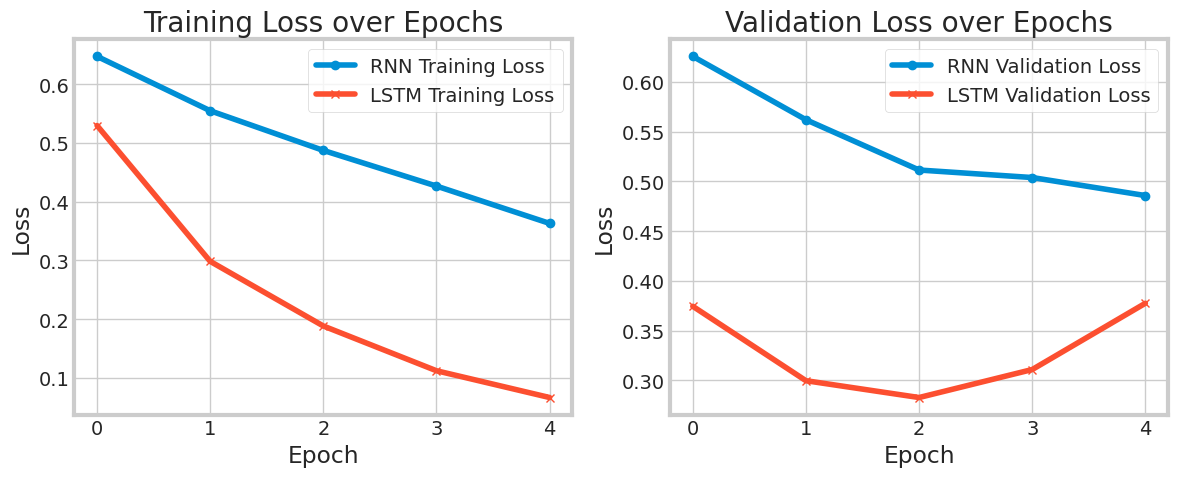

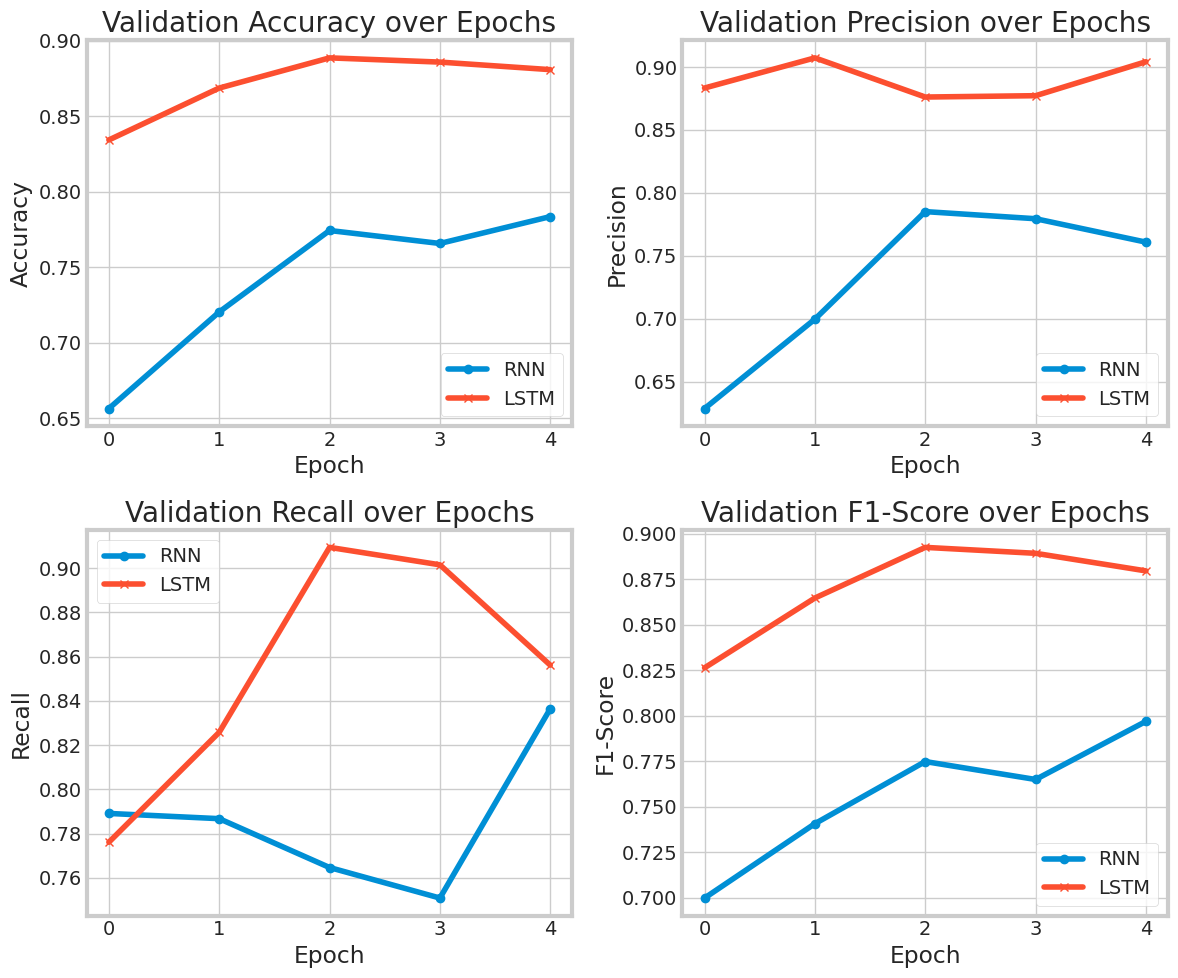

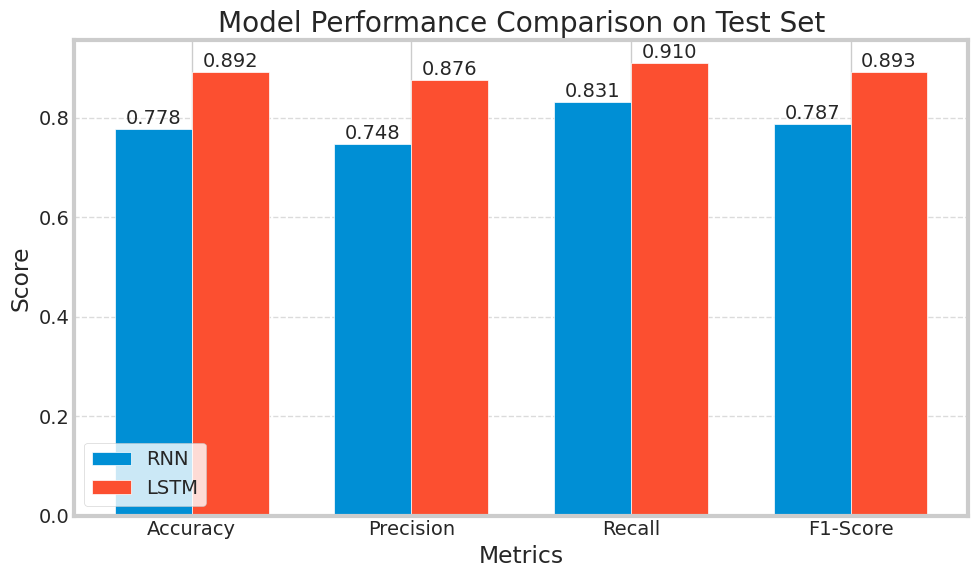

In [24]:
# Visualize training and validation loss
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(rnn_history['train_losses'], label='RNN Training Loss', marker='o')
plt.plot(lstm_history['train_losses'], label='LSTM Training Loss', marker='x')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot validation loss
plt.subplot(1, 2, 2)
plt.plot(rnn_history['val_losses'], label='RNN Validation Loss', marker='o')
plt.plot(lstm_history['val_losses'], label='LSTM Validation Loss', marker='x')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Extract validation accuracy from metrics
rnn_val_accuracy = [m['accuracy'] for m in rnn_history['val_metrics']]
lstm_val_accuracy = [m['accuracy'] for m in lstm_history['val_metrics']]

# Visualize validation metrics
plt.figure(figsize=(12, 10))

# Plot validation accuracy
plt.subplot(2, 2, 1)
plt.plot(rnn_val_accuracy, label='RNN', marker='o')
plt.plot(lstm_val_accuracy, label='LSTM', marker='x')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot validation precision
plt.subplot(2, 2, 2)
plt.plot([m['precision'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['precision'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# Plot validation recall
plt.subplot(2, 2, 3)
plt.plot([m['recall'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['recall'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

# Plot validation F1-score
plt.subplot(2, 2, 4)
plt.plot([m['f1_score'] for m in rnn_history['val_metrics']], label='RNN', marker='o')
plt.plot([m['f1_score'] for m in lstm_history['val_metrics']], label='LSTM', marker='x')
plt.title('Validation F1-Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Create a bar chart for test metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rnn_values = [rnn_metrics['accuracy'], rnn_metrics['precision'],
              rnn_metrics['recall'], rnn_metrics['f1_score']]
lstm_values = [lstm_metrics['accuracy'], lstm_metrics['precision'],
               lstm_metrics['recall'], lstm_metrics['f1_score']]

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, rnn_values, width, label='RNN')
plt.bar(x + width/2, lstm_values, width, label='LSTM')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison on Test Set')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, v in enumerate(rnn_values):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center')

for i, v in enumerate(lstm_values):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## **10. Model Inference with User Input**

In this section, we'll demonstrate how to use our trained models to analyze the sentiment of user-provided movie reviews. We'll create a function that:

1. Preprocesses the text input in the same way as our training data
2. Converts the text to numerical sequences using our vocabulary
3. Pads the sequences to a fixed length
4. Passes the processed input through both models
5. Returns the sentiment prediction and confidence score

This will allow us to interactively test our models on custom inputs and compare their performance.

In [31]:
def predict_sentiment(model, review_text, device, sequence_length=200):
    """
    Predict sentiment of a review text using a trained model.

    Parameters:
    -----------
    model : torch.nn.Module
        Trained sentiment analysis model
    review_text : str
        The text of the review to analyze
    device : torch.device
        Device to run inference on (CPU or GPU)
    sequence_length : int, default=200
        The fixed length to pad/truncate the input sequence

    Returns:
    --------
    tuple(str, float)
        Predicted sentiment label ('Positive' or 'Negative') and confidence score
    """
    # Set model to evaluation mode
    model.eval()

    # Preprocess the text (same as training data)
    review_text = review_text.lower()  # lowercase
    # review_text = re.sub(r'<.*?>', '', review_text)  # remove HTML tags
    # review_text = re.sub(r'[^a-zA-Z\s]', '', review_text)  # remove non-alphanumeric chars

    review_text = ''.join([c for c in review_text if c not in punctuation])
    # Tokenize the review
    words = review_text.split()


    # Convert words to indices using vocabulary
    word_indices = []
    for word in words:
        if word in vocab_to_int:
            word_indices.append(vocab_to_int[word])
        else:
            # Use a special token for unknown words
            word_indices.append(0)  # 0 is our padding token, also use for unknown

    # Pad or truncate sequence to fixed length
    if len(word_indices) > sequence_length:
        word_indices = word_indices[-sequence_length:]  # truncate
    else:
        zeros = [0] * (sequence_length - len(word_indices))
        word_indices = zeros + word_indices  # pad

    # Convert to tensor and add batch dimension
    inputs = torch.tensor(word_indices).unsqueeze(0).to(device)

    # Initialize hidden state
    h = model.init_hidden(1)
    if device == torch.device("cuda"):
        if isinstance(h, tuple):  # LSTM
            h = tuple([each.detach().cuda() for each in h])
        else:  # RNN
            h = h.detach().cuda()

    # Make prediction
    with torch.no_grad():
        output, _ = model(inputs, h)

    # Get prediction probability
    prob = output.item()

    # Determine sentiment label
    if prob >= 0.5:
        sentiment = 'Positive'
    else:
        sentiment = 'Negative'

    # Calculate confidence percentage
    confidence = prob if prob >= 0.5 else 1 - prob
    confidence_pct = confidence * 100

    return sentiment, confidence_pct


def analyze_review(review_text):
    """
    Analyze a review using both RNN and LSTM models for comparison.

    Parameters:
    -----------
    review_text : str
        The text of the review to analyze
    """
    print("\n" + "="*60)
    print(f"Analyzing review: {review_text[:100]}..." if len(review_text) > 100 else f"Analyzing review: {review_text}")
    print("="*60)

    # Make predictions with both models
    rnn_sentiment, rnn_confidence = predict_sentiment(rnn_model, review_text, device)
    lstm_sentiment, lstm_confidence = predict_sentiment(lstm_model, review_text, device)

    # Print results
    print("\nResults:")
    print(f"RNN Model: {rnn_sentiment} (Confidence: {rnn_confidence:.2f}%)")
    print(f"LSTM Model: {lstm_sentiment} (Confidence: {lstm_confidence:.2f}%)")

    # Check if models agree
    if rnn_sentiment == lstm_sentiment:
        print(f"\nBoth models agree: This review expresses {rnn_sentiment.lower()} sentiment.")
    else:
        print("\nModels disagree on sentiment classification.")
        print(f"RNN predicts {rnn_sentiment.lower()} with {rnn_confidence:.2f}% confidence.")
        print(f"LSTM predicts {lstm_sentiment.lower()} with {lstm_confidence:.2f}% confidence.")
        print("Consider the model with higher confidence or review the text further.")


# Test with a few example reviews
example_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start to finish.",
    "I was very disappointed with this film. The characters were poorly developed and the story made no sense at all.",
    "It was an okay movie. Some parts were good but others were boring. Not great, not terrible.",
    "The special effects were amazing but everything else about this movie was terrible."
]

# Analyze each example review
for i, review in enumerate(example_reviews):
    print(f"\nExample {i+1}:")
    analyze_review(review)


# Interactive input for user reviews
print("\n" + "="*60)
print("Enter your own movie review to analyze (or type 'exit' to quit):")
print("="*60)

while True:
    user_input = input("\nEnter a movie review: ")
    if user_input.lower() == 'exit':
        print("Exiting sentiment analysis.")
        break
    if not user_input.strip():
        print("Please enter a review or type 'exit'.")
        continue

    analyze_review(user_input)


Example 1:

Analyzing review: This movie was absolutely fantastic! The acting was superb and the plot kept me engaged from start t...

Results:
RNN Model: Positive (Confidence: 64.29%)
LSTM Model: Positive (Confidence: 98.51%)

Both models agree: This review expresses positive sentiment.

Example 2:

Analyzing review: I was very disappointed with this film. The characters were poorly developed and the story made no s...

Results:
RNN Model: Negative (Confidence: 82.57%)
LSTM Model: Negative (Confidence: 99.72%)

Both models agree: This review expresses negative sentiment.

Example 3:

Analyzing review: It was an okay movie. Some parts were good but others were boring. Not great, not terrible.

Results:
RNN Model: Negative (Confidence: 88.43%)
LSTM Model: Negative (Confidence: 98.86%)

Both models agree: This review expresses negative sentiment.

Example 4:

Analyzing review: The special effects were amazing but everything else about this movie was terrible.

Results:
RNN Model: Negati

KeyboardInterrupt: Interrupted by user